<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/mse_logo.png" width="400" align="right"/>
<div style="text-align: left"> <b> Machine Learning FTP_MachLe </b> <br> HS 2026 <br> <a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

In [2]:
# imports
from IPython.display import Image, display
from IPython.display import HTML
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# allow plots to appear directly in the notebook
%matplotlib inline

# raw URL of this repository on GitHub (images, data)
filepath = "https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main"

ModuleNotFoundError: No module named 'seaborn'

# **Feature Engineering – Group 4: Feature Selection I**

**Authors:** *Name 1, Name 2, Name 3, ...*

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/images/04_Feature_Selection_1.png" width="1200"/>

## Introduction

**What is it about?**
*Feature selection* means choosing a subset of the available features that carries most of the relevant information about the target. *Univariate* (filter) methods score every feature individually against the target, independent of any learning algorithm: Pearson correlation measures linear dependence, the F-test (`f_regression`) tests the significance of a linear relationship, the Maximal Information Coefficient (MIC) and mutual information also detect non-linear dependencies, and the $\chi^2$ test assesses the dependence between non-negative/categorical features and a class label.

**Where is it used?**
Filter methods are a fast first step whenever there are many candidate features: gene-expression data with thousands of genes, text classification with large vocabularies, sensor data with many channels, or engineered feature sets from automated pipelines. In scikit-learn they are available via `SelectKBest`, `SelectPercentile`, `f_regression`, `mutual_info_regression` and `chi2`.

**Why is it important for Machine Learning?**
Irrelevant and redundant features increase variance and thus the risk of overfitting, slow down training and make models harder to interpret. In terms of the bias–variance tradeoff, removing uninformative features reduces variance at little cost in bias. Univariate methods are cheap and easy to explain, but they ignore interactions between features, which is an important limitation to understand.

## (i) Why feature selection helps (bias–variance tradeoff)



## (ii) Univariate feature selection



### Pearson correlation



### F-regression




# Maximal Information Coefficient (MIC)

## 1. What is MIC?

The **Maximal Information Coefficient (MIC)** is a statistical measure that quantifies the strength of dependence between two variables, regardless of whether their relationship is linear or nonlinear.

**Key properties:**
- MIC ranges from **0 to 1**.
- **MIC ≈ 0:** Little or no detected statistical dependence.
- **MIC ≈ 1:** Very strong statistical dependence.
- MIC detects linear, nonlinear, and other complex relationships.
- MIC does not indicate causality or the direction of a relationship.

**Main idea:** MIC measures how strongly an input feature $X$ is related to an output variable $Y$ without assuming a specific functional relationship.

---

## 2. Example: A Nonlinear Relationship

Consider the following function:

$$
Y = X^2
$$

We generate input values between -3 and 3 and calculate the corresponding outputs.

| Input (X) | Output (Y = X²) |
|---|---|
| -3 | 9 |
| -2 | 4 |
| -1 | 1 |
| 0 | 0 |
| 1 | 1 |
| 2 | 4 |
| 3 | 9 |

**Observations:**
- The relationship is nonlinear (U-shaped).
- Each input value determines exactly one output value.
- There is a strong dependency between X and Y.
- MIC can detect this relationship.

**Question:** How can MIC identify this relationship?

---

## 3. How Does MIC Work?

MIC searches for the grid partition that captures the strongest statistical dependence between X and Y.

### Step 1: Divide the Data into a Grid

The scatter plot is divided into rectangular cells using a grid.

For example:
- A 2 × 2 grid creates 4 cells.
- A 3 × 2 grid creates 6 cells.
- A 4 × 4 grid creates 16 cells.

Each observation belongs to one cell based on its X and Y values.

### Step 2: Calculate Mutual Information

Mutual Information (MI) measures how much information one variable provides about another.

$$
I(X;Y) =
\sum_x \sum_y
p(x,y)
\log_2
\left(
\frac{p(x,y)}{p(x)p(y)}
\right)
$$

Where:

- $p(x,y)$: Joint probability that X belongs to category x AND Y belongs to category y.
- $p(x)$: Probability that X belongs to category x.
- $p(y)$: Probability that Y belongs to category y.

If X and Y are independent:

$$
p(x,y) = p(x)p(y)
$$

Therefore:

$$
I(X;Y)=0
$$

### Step 3: Normalize Mutual Information

Different grid sizes have different maximum possible Mutual Information values.

To make the values comparable, MIC uses normalization:

$$
\text{Normalized MI} =
\frac{I(X;Y)}
{\log_2(\min(n_x,n_y))}
$$

Where:
- $n_x$: Number of columns.
- $n_y$: Number of rows.
- $\min(n_x,n_y)$: Smaller number of grid divisions.

The normalized value ranges from 0 to 1.

### Step 4: Evaluate Different Grids

MIC evaluates multiple grid configurations and grid boundaries.

For each grid:
1. Count the observations in each cell.
2. Calculate joint and marginal probabilities.
3. Compute Mutual Information.
4. Normalize the result.

### Step 5: Select the Maximum

MIC selects the maximum normalized Mutual Information across the allowed grid partitions.

$$
\boxed{
MIC(X,Y)=
\max_{\substack{n_x,n_y\geq 2\\n_x n_y\leq B(n)}}
\frac{I^*(X,Y;n_x,n_y)}
{\log_2(\min(n_x,n_y))}
}
$$

Where:

- $I^*$: Maximum Mutual Information among grid partitions with the specified number of rows and columns.
- $B(n)$: Maximum grid complexity allowed for a dataset of size n.
- $\max$: Selects the highest normalized value.

---

## 4. Numerical Example: Mutual Information

Consider the relationship:

$$
Y=X^2
$$

We divide X into three categories:

- **Left:** X < -1.5
- **Middle:** -1.5 ≤ X < 1.5
- **Right:** X ≥ 1.5

And Y into two categories:

- **Low:** Y < 2.25
- **High:** Y ≥ 2.25

This produces a **3 × 2 grid**.

For a symmetric continuous input distribution over [-3,3], the theoretical joint probabilities are:

| X Category | Y Low | Y High |
|---|---|---|
| Left | 0 | 0.25 |
| Middle | 0.50 | 0 |
| Right | 0 | 0.25 |

The marginal probabilities are:

$$
p(X) = (0.25, 0.50, 0.25)
$$

$$
p(Y) = (0.50, 0.50)
$$

We now calculate Mutual Information:

$$
I(X;Y)=
\sum_{x,y} p(x,y)
\log_2\left(\frac{p(x,y)}{p(x)p(y)}\right)
$$

Only cells with nonzero probabilities contribute:

$$
I(X;Y)=
0.25\log_2\left(\frac{0.25}{0.25\cdot0.5}\right)
+
0.5\log_2\left(\frac{0.5}{0.5\cdot0.5}\right)
+
0.25\log_2\left(\frac{0.25}{0.25\cdot0.5}\right)
$$

Simplifying:

$$
I(X;Y)=0.25+0.5+0.25
$$

$$
\boxed{I(X;Y)=1\text{ bit}}
$$

Now normalize:

$$
\text{Normalized MI}=
\frac{1}{\log_2(\min(3,2))}
$$

$$
=\frac{1}{\log_2(2)}=1
$$

**Interpretation:**

Knowing the X category allows us to determine the Y category perfectly.

This grid reaches the maximum possible normalized Mutual Information.

Therefore, MIC also reaches 1 when this grid partition is allowed.

For a finite sample, the exact values can differ slightly.

---

## 5. MIC and Noise

In real-world datasets, relationships are usually not perfectly deterministic.

Consider:

$$
Y = X^2 + \varepsilon
$$

Where $\varepsilon$ represents random noise.

**Expected behaviour:**
- Without noise, MIC can detect a nearly perfect relationship.
- With noise, the statistical dependence generally becomes weaker.
- MIC may decrease as noise increases.

The exact MIC value depends on the data and the estimation procedure.

---

## 6. Key Takeaways

- **MIC measures statistical dependence between two variables.**
- It detects both linear and nonlinear relationships.
- It works by evaluating different grid partitions.
- For each grid, Mutual Information is calculated and normalized.
- The maximum normalized value determines MIC.
- MIC ranges from 0 to 1.
- MIC does not imply causality.

**Main takeaway:**

> MIC identifies statistical dependencies without assuming a specific functional form between the input and output variables.




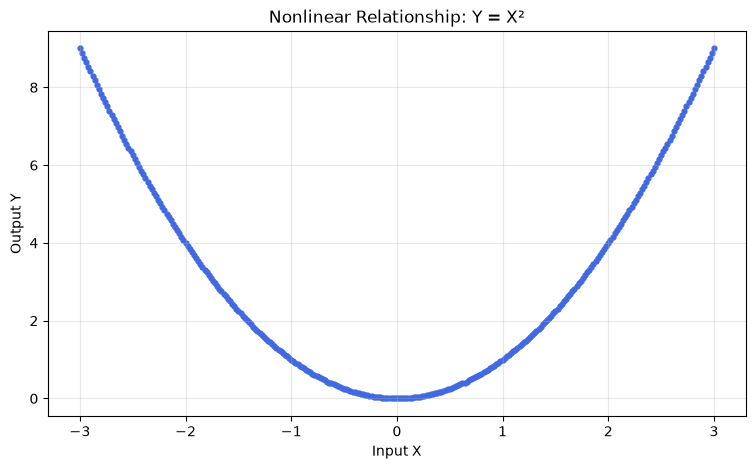

In [8]:
##Grafik 1: Nonlinear Relationship

import numpy as np
import matplotlib.pyplot as plt

# Generate data
x = np.linspace(-3, 3, 301)
y = x**2

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=12, color="royalblue")

plt.title("Nonlinear Relationship: Y = X²")
plt.xlabel("Input X")
plt.ylabel("Output Y")
plt.grid(alpha=0.3)
plt.show()


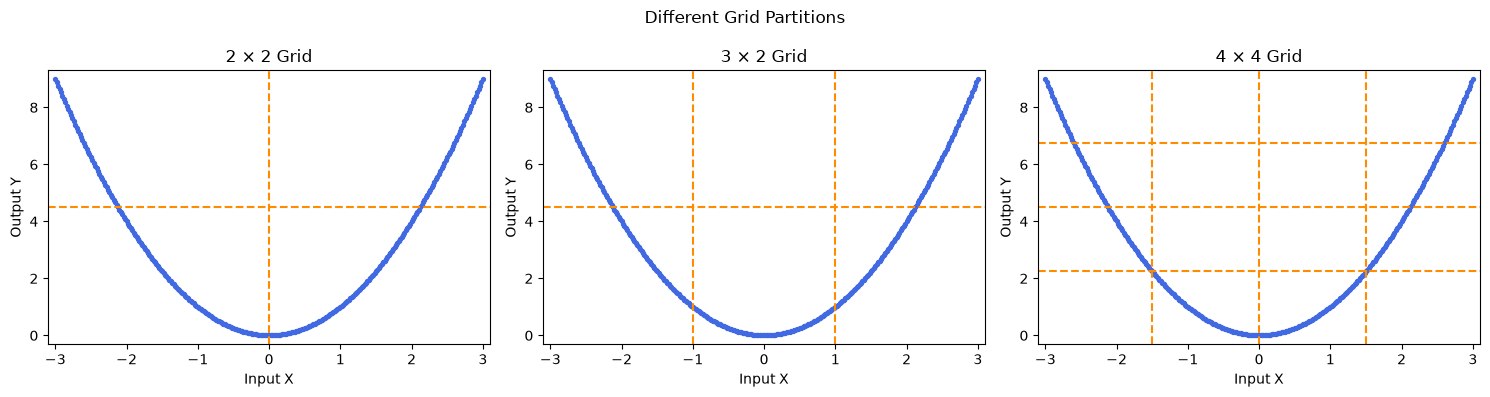

In [9]:
##Grafik 2: Different Grid Partitions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

grid_sizes = [(2, 2), (3, 2), (4, 4)]

for ax, (nx, ny) in zip(axes, grid_sizes):
    ax.scatter(x, y, s=8, color="royalblue")

    x_edges = np.linspace(-3, 3, nx + 1)
    y_edges = np.linspace(0, 9, ny + 1)

    for edge in x_edges[1:-1]:
        ax.axvline(edge, color="darkorange", linestyle="--")

    for edge in y_edges[1:-1]:
        ax.axhline(edge, color="darkorange", linestyle="--")

    ax.set_title(f"{nx} × {ny} Grid")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Output Y")
    ax.set_xlim(-3.1, 3.1)
    ax.set_ylim(-0.3, 9.3)

plt.suptitle("Different Grid Partitions")
plt.tight_layout()
plt.show()


Grid cell counts:
[[  0  75]
 [149   1]
 [  0  76]]

Joint probabilities:
[[0.    0.249]
 [0.495 0.003]
 [0.    0.252]]

Mutual Information: 0.9711 bits
Normalized MI: 0.9711


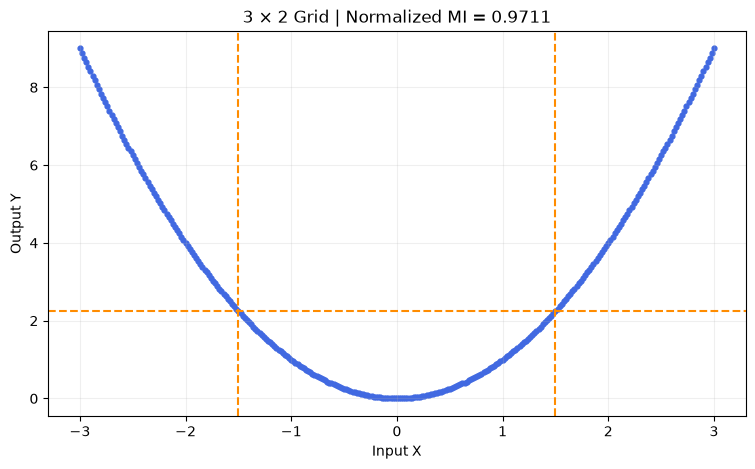

In [10]:
##Grafik 3: Mutual Information Calculation

import numpy as np
import matplotlib.pyplot as plt

# Generate data
x = np.linspace(-3, 3, 301)
y = x**2

# Define grid boundaries
x_edges = [-np.inf, -1.5, 1.5, np.inf]
y_edges = [-np.inf, 2.25, np.inf]

# Assign data points to categories
x_bins = np.digitize(x, x_edges[1:-1])
y_bins = np.digitize(y, y_edges[1:-1])

# Count observations in grid cells
counts = np.zeros((3, 2), dtype=int)

for xi, yi in zip(x_bins, y_bins):
    counts[xi, yi] += 1

# Compute probabilities
p_xy = counts / counts.sum()
p_x = p_xy.sum(axis=1)
p_y = p_xy.sum(axis=0)

# Calculate Mutual Information
mi = 0.0

for i in range(3):
    for j in range(2):
        if p_xy[i, j] > 0:
            mi += p_xy[i, j] * np.log2(
                p_xy[i, j] / (p_x[i] * p_y[j])
            )

# Normalize
normalized_mi = mi / np.log2(2)

print("Grid cell counts:")
print(counts)

print("\nJoint probabilities:")
print(np.round(p_xy, 3))

print(f"\nMutual Information: {mi:.4f} bits")
print(f"Normalized MI: {normalized_mi:.4f}")

# Visualize grid
plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=12, color="royalblue")

plt.axvline(-1.5, color="darkorange", ls="--")
plt.axvline(1.5, color="darkorange", ls="--")
plt.axhline(2.25, color="darkorange", ls="--")

plt.title(f"3 × 2 Grid | Normalized MI = {normalized_mi:.4f}")
plt.xlabel("Input X")
plt.ylabel("Output Y")
plt.grid(alpha=0.2)
plt.show()


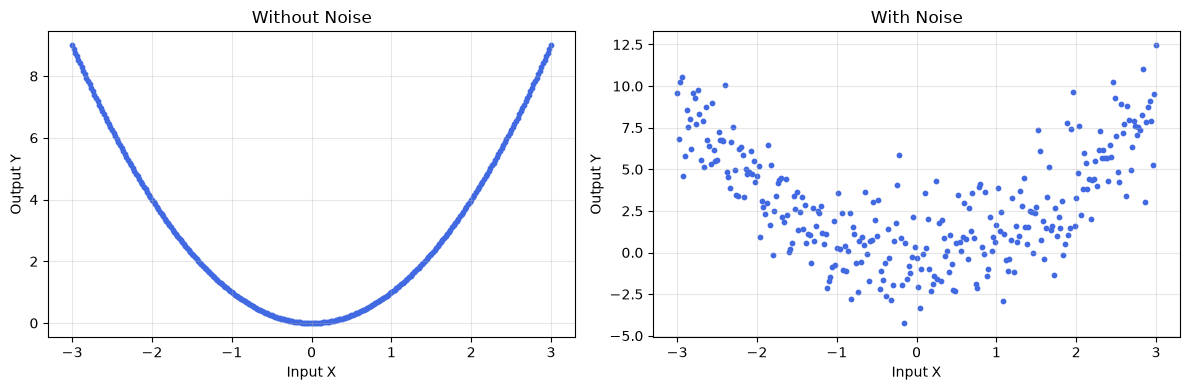

In [11]:
##Grafik 4: Effect of Noise

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

x = np.linspace(-3, 3, 301)
y_clean = x**2
y_noisy = x**2 + rng.normal(0, 2, len(x))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x, y_clean, s=10, color="royalblue")
axes[0].set_title("Without Noise")

axes[1].scatter(x, y_noisy, s=10, color="royalblue")
axes[1].set_title("With Noise")

for ax in axes:
    ax.set_xlabel("Input X")
    ax.set_ylabel("Output Y")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### $\chi^2$ test



## Takeaways

- **What should every ML practitioner remember?**
  - ...
- **What are common pitfalls?**
  - ...
- **When does this technique really matter?**
  - ...

## References

*Cite the sources of all figures, diagrams and code snippets (URLs are sufficient).*

1. ...